# Step 6 — Weather conditional on delay propagation

Adds horizon-aware features of the previous leg flown by the same aircraft and measures how much weather still contributes once this information is known (paper Sect. 3.3 and 5.3, Tables 7–8).

- **Input:** `data/raw/bts/Combined_Flights_<year>.parquet` (all states), `data/processed/flights_clean.parquet`, `data/processed/wx_H*.parquet`
- **Output:** `results/results_propagation.csv`, `results/results_propagation_wxgain.csv`

**Leakage control.** At issuance time `t0 = t_dep − H` only information realized before `t0` is used:

| Previous-leg status at `t0` | Available information |
|---|---|
| Arrived | departure and arrival delay |
| Airborne | departure delay |
| Not yet departed | minutes overdue (if past its scheduled departure) |
| None | — |

Unavailable values are left missing.

### Configuration
Grid per horizon H ∈ {0, 2, 6}: `none` (schedule only), `prop` (+ previous leg), `both` (+ weather), `both+prop` (+ both). Use 0.1 for a quick test run

In [1]:
import glob, time, gc, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import lightgbm as lgb
import airportsdata
from sklearn.model_selection import KFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, roc_auc_score,
                             average_precision_score, precision_recall_curve, f1_score)

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'README.md').exists())  # project root
warnings.filterwarnings('ignore')

DATA = ROOT / 'data' / 'processed'
RESULTS = ROOT / 'results'; RESULTS.mkdir(parents=True, exist_ok=True)
HORIZONS = [0, 2, 6]
SEEDS = [42]
SAMPLE = 0.1                 # use 0.1 for a quick test run
N_BOOT = 1000
TRAIN_END, VAL_END = '2022-01-01', '2022-05-01'
MAX_TURN_H = 12              # max scheduled gap (h) between previous arrival and this departure

### Aircraft rotations from the complete BTS file
For all non-cancelled, non-diverted legs (all states): scheduled and actual departure/arrival times in UTC (same method as `03_flights_information_settings.ipynb`). Legs are sorted by (tail number, scheduled departure); the preceding leg is accepted as the previous leg if it is flown by the same aircraft, arrives at the current origin, and is scheduled to arrive at most `MAX_TURN_H` hours earlier.

In [2]:
COLS = ['FlightDate', 'Tail_Number', 'Origin', 'Dest', 'CRSDepTime', 'CRSElapsedTime',
        'DepDelay', 'ArrDelay', 'Cancelled', 'Diverted']
parts = []
for f in sorted(glob.glob(str(ROOT / 'data' / 'raw' / 'bts' / 'Combined_Flights_*.parquet'))):
    d = pd.read_parquet(f, columns=COLS)
    d = d[(d['Cancelled'] == False) & (d['Diverted'] == False)].drop(columns=['Cancelled', 'Diverted'])
    d = d.dropna(subset=['Tail_Number', 'CRSElapsedTime', 'DepDelay', 'ArrDelay'])
    parts.append(d)
    print(f'  {f}: {len(d):,}')
rot = pd.concat(parts, ignore_index=True); del parts
rot['FlightDate'] = pd.to_datetime(rot['FlightDate'])

ap = airportsdata.load('IATA')
hhmm = rot['CRSDepTime'].astype(int)
local = rot['FlightDate'] + pd.to_timedelta((hhmm // 100) * 60 + hhmm % 100, unit='m')
sdep = pd.Series(pd.NaT, index=rot.index, dtype='datetime64[ns]')
for code, idx in rot.groupby('Origin').groups.items():
    tz = ap.get(code, {}).get('tz')
    if tz is None:
        continue
    sdep.loc[idx] = (local.loc[idx].dt.tz_localize(tz, ambiguous='NaT', nonexistent='shift_forward')
                     .dt.tz_convert('UTC').dt.tz_localize(None).values)
rot['sdep'] = sdep
rot = rot.dropna(subset=['sdep']).reset_index(drop=True)
rot['sarr'] = rot['sdep'] + pd.to_timedelta(rot['CRSElapsedTime'], unit='m')
rot['adep'] = rot['sdep'] + pd.to_timedelta(rot['DepDelay'], unit='m')
rot['aarr'] = rot['sarr'] + pd.to_timedelta(rot['ArrDelay'], unit='m')

rot = rot.sort_values(['Tail_Number', 'sdep']).reset_index(drop=True)
same_tail = rot['Tail_Number'].eq(rot['Tail_Number'].shift(1))
prev = rot[['Dest', 'sdep', 'sarr', 'adep', 'aarr', 'DepDelay', 'ArrDelay']].shift(1)
gap_h = (rot['sdep'] - prev['sarr']).dt.total_seconds() / 3600
valid = same_tail & prev['Dest'].eq(rot['Origin']) & (gap_h >= 0) & (gap_h <= MAX_TURN_H)
print(f'{len(rot):,} legs; valid previous leg: {valid.mean():.1%}')

rot_feat = pd.DataFrame({
    'Tail_Number': rot['Tail_Number'], 'Origin': rot['Origin'], 'sdep': rot['sdep'],
    'p_sdep': prev['sdep'].where(valid), 'p_sarr': prev['sarr'].where(valid),
    'p_adep': prev['adep'].where(valid), 'p_aarr': prev['aarr'].where(valid),
    'p_depdelay': prev['DepDelay'].where(valid), 'p_arrdelay': prev['ArrDelay'].where(valid),
})
rot_feat = rot_feat.drop_duplicates(subset=['Tail_Number', 'Origin', 'sdep'], keep=False)
del rot, prev, sdep, local; gc.collect()

  c:\Users\Admin\Downloads\on-going assement 1\source_code - Copy\data\raw\bts\Combined_Flights_2018.parquet: 5,585,544
  c:\Users\Admin\Downloads\on-going assement 1\source_code - Copy\data\raw\bts\Combined_Flights_2019.parquet: 7,917,263
  c:\Users\Admin\Downloads\on-going assement 1\source_code - Copy\data\raw\bts\Combined_Flights_2020.parquet: 4,712,930
  c:\Users\Admin\Downloads\on-going assement 1\source_code - Copy\data\raw\bts\Combined_Flights_2021.parquet: 6,185,870
  c:\Users\Admin\Downloads\on-going assement 1\source_code - Copy\data\raw\bts\Combined_Flights_2022.parquet: 3,944,916
28,343,501 legs; valid previous leg: 90.4%


42

### Join previous legs to the flight table
Join key: (tail number, origin, scheduled UTC departure).

In [3]:
BASE_NUM = ['Month', 'DayOfWeek', 'CRSDepHour', 'CRSArrHour', 'CRSElapsedTime', 'Distance',
            'DistanceGroup', 'DepHour_sin', 'DepHour_cos', 'Month_sin', 'Month_cos',
            'DoW_sin', 'DoW_cos', 'IsWeekend', 'IsPeakHour', 'IsHoliday']
HIGH_CARD = ['Origin', 'Dest', 'Airline', 'Tail_Number']
LOW_CARD = ['OriginState', 'DestState', 'DepTimeBlk']
df = pd.read_parquet(DATA / 'flights_clean.parquet',
                     columns=['row_id', 'FlightDate', 'dep_utc', 'ArrDelayMinutes', 'ArrDel15'] + BASE_NUM + HIGH_CARD + LOW_CARD)
df['dep_utc'] = df['dep_utc'].astype('datetime64[ns]')
m = df[['Tail_Number', 'Origin', 'dep_utc']].merge(
    rot_feat.rename(columns={'sdep': 'dep_utc'}), on=['Tail_Number', 'Origin', 'dep_utc'], how='left')
assert len(m) == len(df)
P = m.drop(columns=['Tail_Number', 'Origin']).reset_index(drop=True)
del m, rot_feat; gc.collect()
print(f'Study flights with a previous leg: {P["p_sdep"].notna().mean():.1%}')

Study flights with a previous leg: 89.9%


### Horizon-aware propagation features

| Feature | Meaning | Available when |
|---|---|---|
| `prev_status` | −1 none, 0 not departed, 1 airborne, 2 arrived | always |
| `prev_dep_delay` | departure delay of the previous leg | departed before `t0` |
| `prev_arr_delay` | arrival delay of the previous leg | arrived before `t0` |
| `prev_overdue_min` | minutes past its scheduled departure while still on the ground | not departed, schedule passed |
| `sched_turn_min` | scheduled turnaround | always (schedule) |
| `slack_min` | turnaround slack: scheduled turnaround minus known lateness | always |

In [4]:
def prop_features(H):
    t0 = df['dep_utc'] - pd.Timedelta(hours=H)
    has = P['p_sdep'].notna()
    dep_known = has & (P['p_adep'] <= t0)
    arr_known = has & (P['p_aarr'] <= t0)
    status = np.where(~has, -1, np.where(arr_known, 2, np.where(dep_known, 1, 0)))
    dep_delay = P['p_depdelay'].where(dep_known)
    arr_delay = P['p_arrdelay'].where(arr_known)
    overdue = ((t0 - P['p_sdep']).dt.total_seconds() / 60).clip(lower=0).where(has & ~dep_known)
    turn = (df['dep_utc'] - P['p_sarr']).dt.total_seconds() / 60
    known_late = arr_delay.fillna(dep_delay).fillna(overdue)
    slack = turn - known_late
    out = pd.DataFrame({'prev_status': status, 'prev_dep_delay': dep_delay, 'prev_arr_delay': arr_delay,
                        'prev_overdue_min': overdue, 'sched_turn_min': turn, 'slack_min': slack}).astype('float32')
    # --- Leakage checks ---
    assert not (out['prev_arr_delay'].notna() & ~(P['p_aarr'] <= t0)).any()
    assert not (out['prev_dep_delay'].notna() & ~(P['p_adep'] <= t0)).any()
    return out

for H in HORIZONS:
    s = prop_features(H)['prev_status'].value_counts(normalize=True).sort_index()
    print(f'H{H}: ' + ', '.join(f'{int(k)}={v:.1%}' for k, v in s.items()) +
          '   (-1 none, 0 not departed, 1 airborne, 2 arrived)')

H0: -1=10.1%, 0=0.4%, 1=3.1%, 2=86.4%   (-1 none, 0 not departed, 1 airborne, 2 arrived)
H2: -1=10.1%, 0=10.7%, 1=56.9%, 2=22.3%   (-1 none, 0 not departed, 1 airborne, 2 arrived)
H6: -1=10.1%, 0=68.6%, 1=5.9%, 2=15.4%   (-1 none, 0 not departed, 1 airborne, 2 arrived)


### Targets, split, and out-of-fold target encoding
Identical to `05_modeling_horizon.ipynb`.

In [5]:
tr = (df['FlightDate'] < TRAIN_END).values
va = ((df['FlightDate'] >= TRAIN_END) & (df['FlightDate'] < VAL_END)).values
te = (df['FlightDate'] >= VAL_END).values
if SAMPLE < 1.0:
    tr = tr & (np.random.RandomState(0).rand(len(df)) < SAMPLE)
y_reg = np.minimum(df['ArrDelayMinutes'].astype('float32').values,
                   np.quantile(df['ArrDelayMinutes'].values[tr], 0.999))
y_cls = df['ArrDel15'].astype('int8').values
print(f'Train {tr.sum():,} | Val {va.sum():,} | Test {te.sum():,}')


def target_encode_oof(col, y, m=10.0, n_folds=5, seed=0):
    prior = y[tr].mean(); out = np.full(len(col), np.nan, dtype='float32'); vals = col.values
    def fit_apply(fi, ai):
        s = pd.DataFrame({'k': vals[fi], 'y': y[fi]}).groupby('k')['y'].agg(['sum', 'count'])
        out[ai] = pd.Series(vals[ai]).map((s['sum'] + m * prior) / (s['count'] + m)).fillna(prior).values
    tri = np.where(tr)[0]
    for f_i, a_i in KFold(n_folds, shuffle=True, random_state=seed).split(tri):
        fit_apply(tri[f_i], tri[a_i])
    fit_apply(tri, np.where(~tr)[0])
    return out


X_base = df[BASE_NUM].astype('float32').copy()
for c in HIGH_CARD:
    X_base[f'{c}_te'] = target_encode_oof(df[c].astype(str), y_cls.astype('float32'))
for c in LOW_CARD:
    X_base[c] = df[c].astype('category')
dates_test = df.loc[te, 'FlightDate'].values

Train 855,049 | Val 792,335 | Test 638,672


### Training, evaluation, and bootstrap helpers
Identical to `05_modeling_horizon.ipynb` (memory-efficient `fit_predict`).

In [6]:
def lgb_params(seed, task):
    p = dict(learning_rate=0.05, num_leaves=255, min_data_in_leaf=200, feature_fraction=0.8,
             bagging_fraction=0.8, bagging_freq=5, lambda_l2=1.0, verbose=-1, seed=seed,
             num_threads=-1, max_cat_to_onehot=16)
    p.update(dict(objective='regression', metric='l1') if task == 'reg' else dict(objective='binary', metric='binary_logloss'))
    return p


def fit_predict(X, seed):
    Xva, Xte = X[va], X[te]
    dtr = lgb.Dataset(X[tr], label=y_reg[tr], free_raw_data=True).construct(); gc.collect()
    out = {}
    for task, y in [('reg', y_reg), ('cls', y_cls)]:
        dtr.set_label(y[tr])
        m = lgb.train(lgb_params(seed, task), dtr, num_boost_round=3000,
                      valid_sets=[lgb.Dataset(Xva, label=y[va], reference=dtr)],
                      callbacks=[lgb.early_stopping(100, verbose=False)])
        out[task] = dict(val=m.predict(Xva, num_iteration=m.best_iteration),
                         test=m.predict(Xte, num_iteration=m.best_iteration), model=m)
    del dtr; gc.collect()
    return out


def evaluate(pred):
    pr, pc = pred['reg']['test'], pred['cls']['test']
    prec, rec, thr = precision_recall_curve(y_cls[va], pred['cls']['val'])
    t = thr[np.argmax((2 * prec * rec / (prec + rec + 1e-9))[:-1])]
    return dict(MAE=mean_absolute_error(y_reg[te], pr), RMSE=np.sqrt(mean_squared_error(y_reg[te], pr)),
                R2=r2_score(y_reg[te], pr), AUC=roc_auc_score(y_cls[te], pc),
                PR_AUC=average_precision_score(y_cls[te], pc), F1=f1_score(y_cls[te], pc > t))


def per_day(pred):
    return pd.DataFrame({'d': dates_test, 'ae': np.abs(y_reg[te] - pred['reg']['test']),
                         'br': (pred['cls']['test'] - y_cls[te]) ** 2}).groupby('d').agg(['sum', 'count'])


def boot_ci(a, b, key, n_boot=N_BOOT, seed=0):
    idx = np.random.RandomState(seed).randint(0, len(a), size=(n_boot, len(a)))
    sa, sb, c = a[(key, 'sum')].values, b[(key, 'sum')].values, a[(key, 'count')].values
    d = (sa[idx].sum(1) - sb[idx].sum(1)) / c[idx].sum(1)
    return np.percentile(d, 2.5), np.percentile(d, 97.5)

### Experiment grid
Confidence intervals: `dMAE_vs_none`, `dBrier_vs_none` against the schedule-only model; `dMAE_wx_given_prop` compares `both+prop` with `prop` at the same horizon (does weather still help once the previous leg is known?).

In [7]:
rows, days, models_kept = [], {}, {}
for seed in SEEDS:
    t = time.time()
    pred = fit_predict(X_base, seed)
    rows.append(dict(H='-', config='none', seed=seed, **evaluate(pred)))
    days[('none', seed)] = per_day(pred)
    print(f'[seed {seed}] none  R2={rows[-1]["R2"]:+.4f} AUC={rows[-1]["AUC"]:.4f} ({time.time()-t:.0f}s)')

    for H in HORIZONS:
        PF = prop_features(H)
        W = pd.read_parquet(DATA / f'wx_H{H}.parquet').drop(columns='row_id').astype('float32')
        for config in ['prop', 'both', 'both+prop']:
            parts = [X_base]
            if 'prop' in config:
                parts.append(PF)
            if 'both' in config:
                parts.append(W)
            X = pd.concat(parts, axis=1)
            t = time.time()
            pred = fit_predict(X, seed)
            r = dict(H=f'H{H}', config=config, seed=seed, **evaluate(pred))
            days[(H, config, seed)] = per_day(pred)
            r['dMAE_vs_none_lo'], r['dMAE_vs_none_hi'] = boot_ci(days[(H, config, seed)], days[('none', seed)], 'ae')
            r['dBrier_vs_none_lo'], r['dBrier_vs_none_hi'] = boot_ci(days[(H, config, seed)], days[('none', seed)], 'br')
            if config == 'both+prop':
                r['dBrier_wx_given_prop_lo'], r['dBrier_wx_given_prop_hi'] = boot_ci(
                    days[(H, config, seed)], days[(H, 'prop', seed)], 'br')
                r['dMAE_wx_given_prop_lo'], r['dMAE_wx_given_prop_hi'] = boot_ci(
                    days[(H, config, seed)], days[(H, 'prop', seed)], 'ae')
                if seed == SEEDS[0]:
                    models_kept[H] = (pred['reg']['model'], list(X.columns))
            rows.append(r)
            print(f'[seed {seed}] H{H} {config:10s} R2={r["R2"]:+.4f} AUC={r["AUC"]:.4f} ({time.time()-t:.0f}s)')
            del X; gc.collect()
        del PF, W; gc.collect()

res = pd.DataFrame(rows)
res.to_csv(RESULTS / 'results_propagation.csv', index=False)

[seed 42] none  R2=+0.0249 AUC=0.6611 (13s)
[seed 42] H0 prop       R2=+0.2942 AUC=0.8041 (27s)
[seed 42] H0 both       R2=+0.0578 AUC=0.6896 (43s)
[seed 42] H0 both+prop  R2=+0.3077 AUC=0.8193 (52s)
[seed 42] H2 prop       R2=+0.2041 AUC=0.7634 (18s)
[seed 42] H2 both       R2=+0.0432 AUC=0.6823 (41s)
[seed 42] H2 both+prop  R2=+0.2151 AUC=0.7773 (50s)
[seed 42] H6 prop       R2=+0.0781 AUC=0.6869 (15s)
[seed 42] H6 both       R2=+0.0344 AUC=0.6750 (38s)
[seed 42] H6 both+prop  R2=+0.0859 AUC=0.6987 (41s)


### Summary (paper Tables 7–8)

In [8]:
summ = res.groupby(['H', 'config'])[['MAE', 'RMSE', 'R2', 'AUC', 'PR_AUC', 'F1']].mean().round(4)
none_r2 = res.loc[res['config'] == 'none', 'R2'].mean()
none_auc = res.loc[res['config'] == 'none', 'AUC'].mean()
summ['ΔR2_vs_none'] = (summ['R2'] - none_r2).round(4)
summ['ΔAUC_vs_none'] = (summ['AUC'] - none_auc).round(4)
wx_gain = []
for H in HORIZONS:
    k = f'H{H}'
    wx_gain.append(dict(H=k,
        wx_gain_R2_without_prop=summ.loc[(k, 'both'), 'R2'] - none_r2,
        wx_gain_R2_with_prop=summ.loc[(k, 'both+prop'), 'R2'] - summ.loc[(k, 'prop'), 'R2'],
        wx_gain_AUC_without_prop=summ.loc[(k, 'both'), 'AUC'] - none_auc,
        wx_gain_AUC_with_prop=summ.loc[(k, 'both+prop'), 'AUC'] - summ.loc[(k, 'prop'), 'AUC']))
wx_gain = pd.DataFrame(wx_gain).round(4)
wx_gain.to_csv(RESULTS / 'results_propagation_wxgain.csv', index=False)
display(summ)
wx_gain

MAE     RMSE      R2     AUC  PR_AUC      F1  ΔR2_vs_none  \
H  config                                                                     
-  none       21.2310  43.8505  0.0249  0.6611  0.3637  0.4234      -0.0000   
H0 both       19.8982  43.1057  0.0578  0.6896  0.4221  0.4430       0.0329   
   both+prop  14.8984  36.9505  0.3077  0.8193  0.6977  0.6056       0.2828   
   prop       15.5665  37.3072  0.2942  0.8041  0.6827  0.5885       0.2693   
H2 both       20.3086  43.4373  0.0432  0.6823  0.3995  0.4376       0.0183   
   both+prop  17.1763  39.3441  0.2151  0.7773  0.6081  0.5384       0.1902   
   prop       17.7235  39.6170  0.2041  0.7634  0.5936  0.5201       0.1792   
H6 both       20.6714  43.6380  0.0344  0.6750  0.3830  0.4352       0.0095   
   both+prop  19.7749  42.4571  0.0859  0.6987  0.4310  0.4519       0.0610   
   prop       20.2636  42.6393  0.0781  0.6869  0.4189  0.4336       0.0532   

              ΔAUC_vs_none  
H  config                   
-  none            -0.0000  
H0 both             0.0285  
   both+prop        0.1582  
   prop             0.1430  
H2 both             0.0212  
   both+prop        0.1162  
   prop             0.1023  
H6 both             0.0139  
   both+prop        0.0376  
   prop             0.0258

,H,wx_gain_R2_without_prop,wx_gain_R2_with_prop,wx_gain_AUC_without_prop,wx_gain_AUC_with_prop
0,H0,0.0329,0.0135,0.0285,0.0152
1,H2,0.0183,0.0110,0.0212,0.0139
2,H6,0.0095,0.0078,0.0139,0.0118


### SHAP for `H2 / both+prop` (supplementary)
Exploratory; the figures in the paper are produced by `08_shap_figures.ipynb`.

slack_min           5.456
prev_overdue_min    2.496
prev_dep_delay      2.118
DepTimeBlk          1.206
Month_cos           1.050
DepHour_sin         0.966
Dest_te             0.904
org_dewpt_f         0.899
dst_dewpt_f         0.804
Airline_te          0.783
org_temp_f          0.775
Origin_te           0.642
sched_turn_min      0.605
CRSArrHour          0.580
Tail_Number_te      0.500
CRSDepHour          0.483
org_slp             0.473
DestState           0.420
dst_cloud_max       0.365
DayOfWeek           0.354


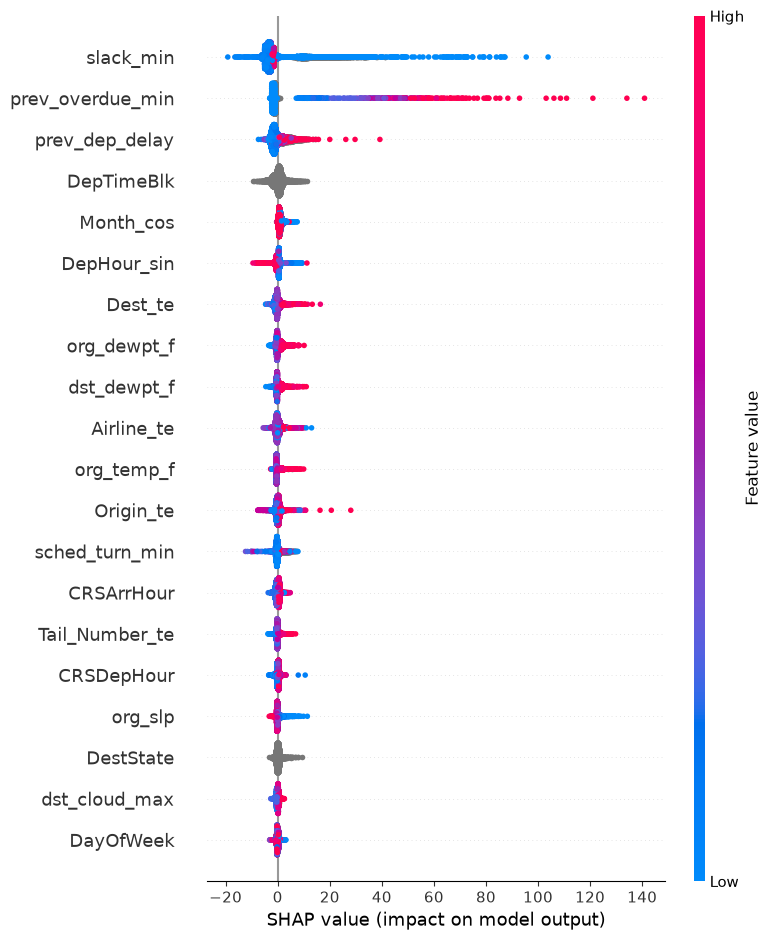

In [9]:
import shap
import matplotlib.pyplot as plt
Hs = 2 if 2 in models_kept else list(models_kept)[0]
model, cols = models_kept[Hs]
X = pd.concat([X_base, prop_features(Hs),
               pd.read_parquet(DATA / f'wx_H{Hs}.parquet').drop(columns='row_id').astype('float32')], axis=1)[cols]
X_shap = X[te].sample(10000, random_state=42); del X
sv = shap.TreeExplainer(model).shap_values(X_shap)
print(pd.Series(np.abs(sv).mean(0), index=X_shap.columns).sort_values(ascending=False).head(20).round(3).to_string())
FIG = ROOT / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
shap.summary_plot(sv, X_shap, max_display=20, show=False)
plt.tight_layout(); plt.savefig(FIG / f'fig_shap_H{Hs}_prop_supplementary.pdf', bbox_inches='tight'); plt.show()